<a href="https://colab.research.google.com/github/ayeshabaig575/FYP/blob/main/fyp3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import necessary libraries
import os
import numpy as np
import pandas as pd
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc # Import roc_curve and auc here
# Import the SVC class
from sklearn.svm import SVC
from tensorflow.keras.layers import Dropout, Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, GlobalAveragePooling2D, Dense
from tensorflow.keras.layers import Dropout
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt
import itertools
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings("ignore")
# Import seaborn
import seaborn as sns # This line imports the seaborn library and assigns it to the alias 'sns'

print('Modules loaded.')

Modules loaded.


In [ ]:
# Generate data paths with labels
data_dir = '/content/drive/MyDrive/Dataset_BUSI_with_GT'
filepaths = []
labels = []

folds = os.listdir(data_dir)
for fold in folds:
    foldpath = os.path.join(data_dir, fold)
    filelist = os.listdir(foldpath)
    for file in filelist:
        fpath = os.path.join(foldpath, file)
        filepaths.append(fpath)
        labels.append(fold)

In [ ]:
# Concatenate data paths with labels into one dataframe
Fseries = pd.Series(filepaths, name='filepaths')
Lseries = pd.Series(labels, name='labels')
df = pd.concat([Fseries, Lseries], axis=1)
strat = df['labels']

In [ ]:
train_df, test_df = train_test_split(df, train_size=0.8, shuffle=True, random_state=123, stratify=strat)


In [ ]:
# Function to load and preprocess images
def load_and_preprocess_images(filepaths, img_size=(224, 224)):
    images = []
    for filepath in filepaths:
        img = cv2.imread(filepath)
        img = cv2.resize(img, img_size)
        img = img.astype('float32')  # Convert to float32
        img = preprocess_input(img)  # Preprocess for DenseNet201
        images.append(img)
    return np.array(images)

In [ ]:
# Load training and testing images
X_train = load_and_preprocess_images(train_df['filepaths'].values)
y_train = train_df['labels'].values
X_test = load_and_preprocess_images(test_df['filepaths'].values)
y_test = test_df['labels'].values

In [ ]:
# Encode labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test) # Encode y_test using the same LabelEncoder

In [ ]:
# Load DenseNet201 model for feature extraction
base_model = DenseNet201(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the last 20 layers of DenseNet201
for layer in base_model.layers[:-20]:  # Freeze all layers except the last 20
    layer.trainable = False

# Add custom layers on top of the base model
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu', kernel_regularizer=l2(0.01))(x)  # L2 Regularization
x = Dropout(0.6)(x)  # Dropout to prevent overfitting
predictions = Dense(len(le.classes_), activation='softmax', kernel_regularizer=l2(0.01))(x)  # L2 Regularization

74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
# Create the complete model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Train the model for 40 epochs
epochs = 40
history = model.fit(X_train, y_train_encoded, validation_split=0.2, epochs=epochs, batch_size=32)


Epoch 1/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.4684 - loss: 5.6702 - val_accuracy: 0.8024 - val_loss: 4.7157
Epoch 2/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 159ms/step - accuracy: 0.7581 - loss: 4.5890 - val_accuracy: 0.8498 - val_loss: 4.1479
Epoch 3/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 153ms/step - accuracy: 0.8239 - loss: 4.0329 - val_accuracy: 0.8656 - val_loss: 3.7137
Epoch 4/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 149ms/step - accuracy: 0.8392 - loss: 3.6367 - val_accuracy: 0.8617 - val_loss: 3.3665
Epoch 5/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 161ms/step - accuracy: 0.8836 - loss: 3.2600 - val_accuracy: 0.8814 - val_loss: 3.0568
Epoch 6/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 149ms/step - accuracy: 0.8844 - loss: 2.9894 - val_accuracy: 0.8933 - val_loss: 2.8003
Epoch 7/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 156ms/step - accuracy: 0.9276 - loss: 2.6956 - val_accuracy: 0.9012 - val_loss: 2.5790
Epoch 8/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 161ms/step - accuracy: 0.9456 - loss: 2.4545 - val_accuracy: 0

In [ ]:
# Extract features using the trained model
X_train_features = model.predict(X_train)
X_test_features = model.predict(X_test)

40/40 ━━━━━━━━━━━━━━━━━━━━ 51s 798ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step


In [ ]:
# Flatten the features
X_train_features = X_train_features.reshape(X_train_features.shape[0], -1)
X_test_features = X_test_features.reshape(X_test_features.shape[0], -1)

In [ ]:
# Train the SVM model
svm_model = SVC(kernel='linear', C=1.0, random_state=43, probability=True)  # Enable probability for ROC curve
svm_model.fit(X_train_features, y_train_encoded)

SVC(kernel='linear', probability=True, random_state=43)

In [ ]:
# Make predictions
y_pred = svm_model.predict(X_test_features)
y_pred_proba = svm_model.predict_proba(X_test_features)  # Probabilities for ROC curve

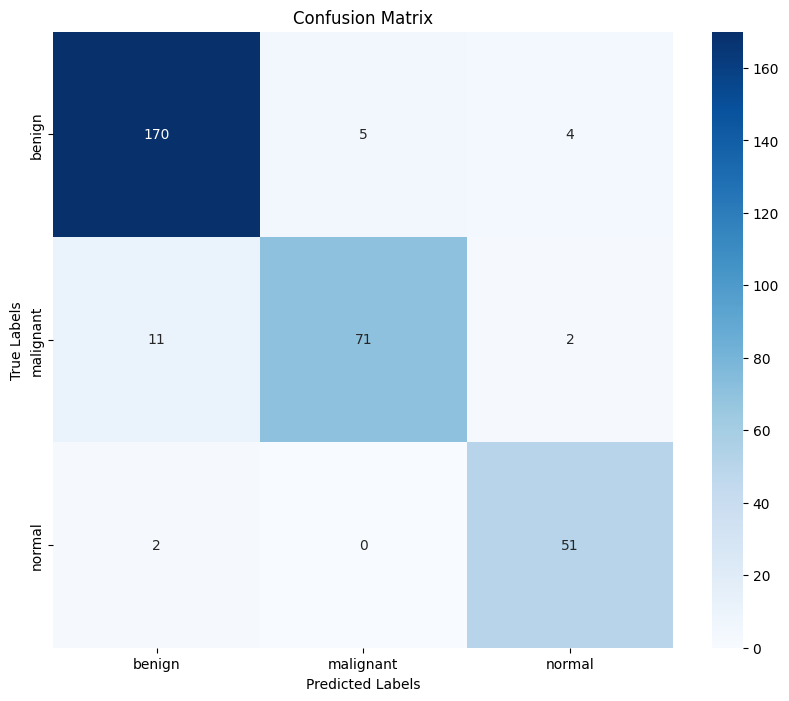

In [ ]:
# 1. Confusion Matrix
cm = confusion_matrix(y_test_encoded, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

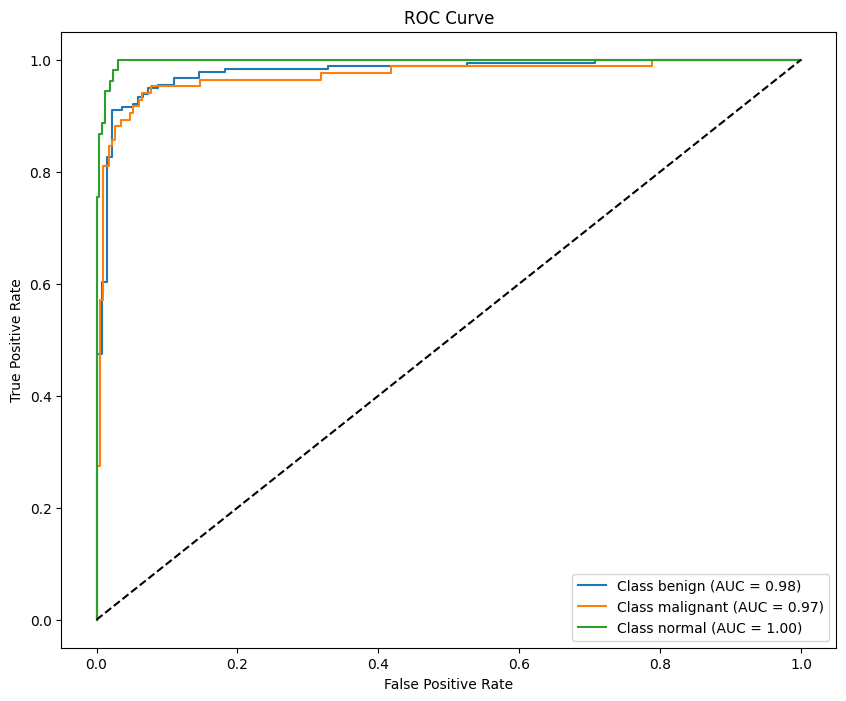

In [ ]:
# 2. ROC Curve and AUC Score
plt.figure(figsize=(10, 8))
for i in range(len(le.classes_)):
    fpr, tpr, _ = roc_curve(y_test_encoded == i, y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {le.classes_[i]} (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [ ]:
# Classification report
print(classification_report(y_test_encoded, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

      benign       0.93      0.95      0.94       179
   malignant       0.93      0.85      0.89        84
      normal       0.89      0.96      0.93        53

    accuracy                           0.92       316
   macro avg       0.92      0.92      0.92       316
weighted avg       0.92      0.92      0.92       316



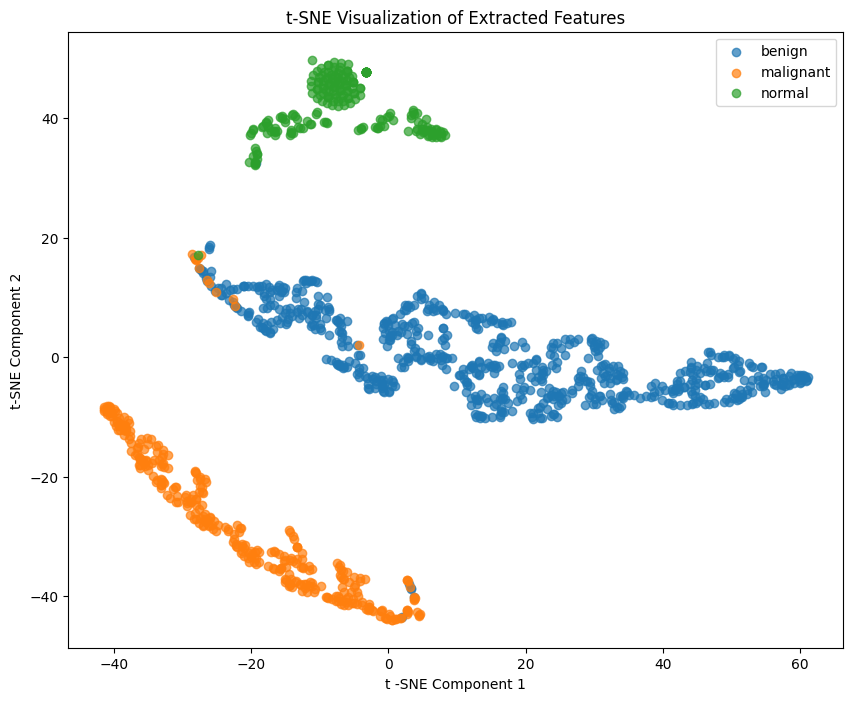

In [ ]:
# 3. t-SNE Visualization of Extracted Features
# Import TSNE
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
X_train_tsne = tsne.fit_transform(X_train_features)

plt.figure(figsize=(10, 8))
for i in range(len(le.classes_)):
    indices = np.where(y_train_encoded == i)
    plt.scatter(X_train_tsne[indices, 0], X_train_tsne[indices, 1], label=le.classes_[i], alpha=0.7)
plt.title('t-SNE Visualization of Extracted Features')
plt.xlabel('t -SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend()
plt.show()

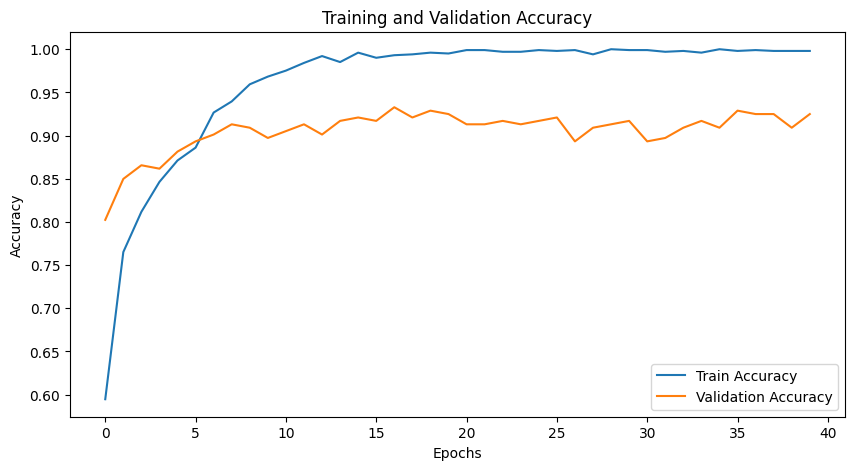

In [ ]:
# Plot Training & Validation Accuracy
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


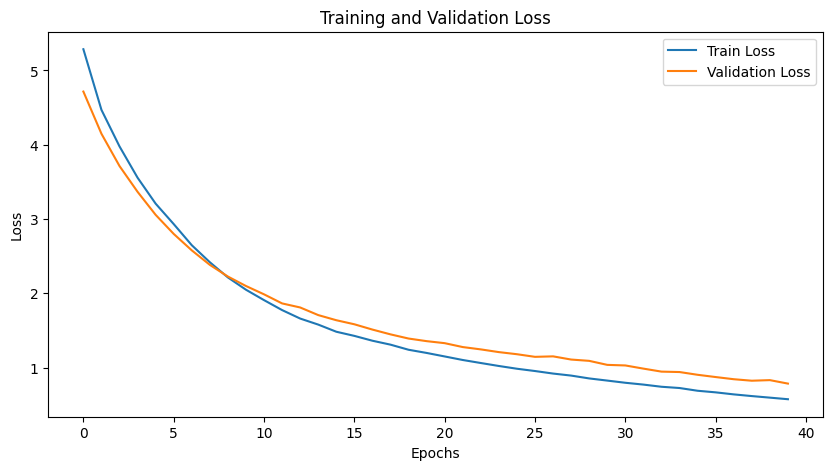

In [ ]:
# Plot Training & Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
# Function to display extracted features
def plot_feature_maps(model, X_sample, layer_name):
    feature_extractor = Model(inputs=model.input,
                              outputs=model.get_layer(layer_name).output)
    feature_maps = feature_extractor.predict(np.expand_dims(X_sample, axis=0))
    feature_maps = np.squeeze(feature_maps)
    num_maps = feature_maps.shape[-1]

    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    for i, ax in enumerate(axes.flat):
        if i < num_maps:
            ax.imshow(feature_maps[:, :, i], cmap='viridis')
            ax.axis('off')
    plt.suptitle(f'Feature Maps from Layer: {layer_name}')
    plt.show()

In [ ]:
# Function to visualize true vs predicted labels
def visualize_predictions(X_test, y_test, y_pred, le, num_samples=10):
    plt.figure(figsize=(15, 5))

    indices = np.random.choice(len(X_test), num_samples, replace=False)
    for i, idx in enumerate(indices):
        img = X_test[idx]
        true_label = le.inverse_transform([y_test[idx]])[0]
        pred_label = le.inverse_transform([y_pred[idx]])[0]

        plt.subplot(2, num_samples // 2, i + 1)
        plt.imshow(cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_BGR2RGB))
        plt.title(f'True: {true_label}\nPred: {pred_label}', fontsize=10)
        plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 23s 23s/step


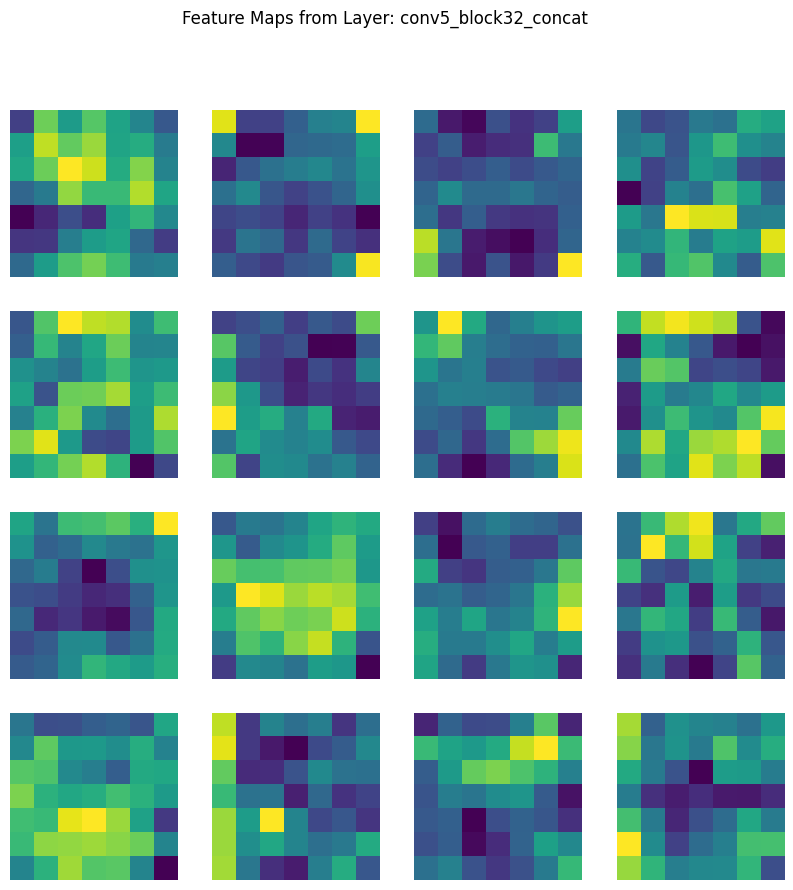

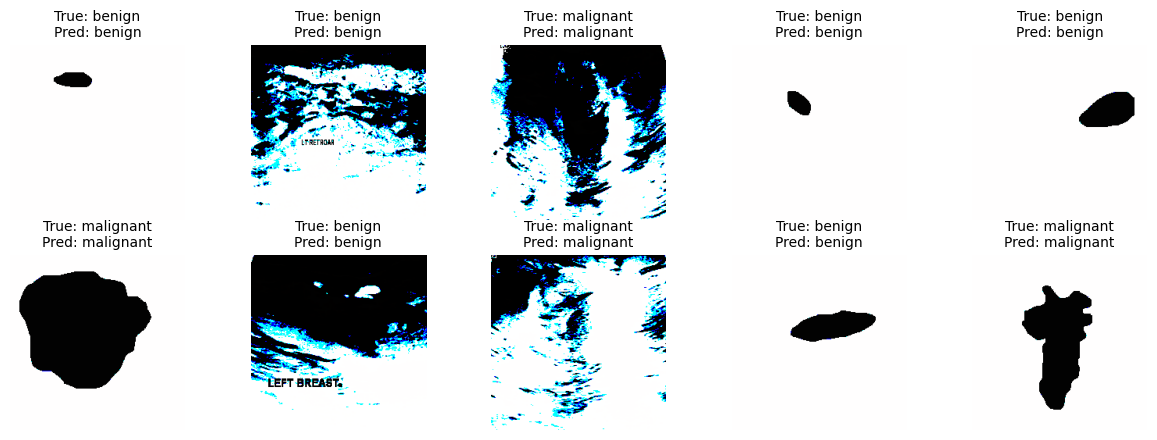

In [ ]:
# Plot extracted feature maps
plot_feature_maps(model, X_test[0], 'conv5_block32_concat')

# Visualize classification results
visualize_predictions(X_test, y_test_encoded, y_pred, le)


In [ ]:
# Import the joblib library
import joblib

# Save the model using joblib
joblib.dump(svm_model, 'svm_model.pkl')

['svm_model.pkl']